In [13]:
import os
from dotenv import load_dotenv
load_dotenv()

if os.environ.get("OPENAI_API_KEY"):
    print("bro it is working")


from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
str_parser = StrOutputParser()

llm_model = init_chat_model(model="gpt-5-nano")

bro it is working


In [14]:
from pydantic import BaseModel, Field
from typing import List, Literal

class llm_schema(BaseModel):
    funny_flag: Literal["funny", "not funny"] = Field(description="Whether the joke is funny or not.")
    feedback : str = Field(description="Feedback on the joke")

llm_with_structuredOuput = llm_model.with_structured_output(llm_schema)
#llm_with_structuredOuput.invoke("vivek is a serious guy")

In [15]:
from typing import List, TypedDict

class graph_schema(TypedDict):
    topic: str
    joke: str
    funny_flag: str
    feedback: str
    max_iterations: int

In [16]:
def generate_node(schema: graph_schema):

    topic = schema["topic"]

    if schema["feedback"]:
        response = llm_model.invoke(f"Plase modify the following joke {schema["joke"]} based on the following feedback {schema["feedback"]}")
    else:
        response = llm_model.invoke(f"Create the small joke about the folowing topic : {topic}")

    schema["joke"] = response.content
    return schema     

In [ ]:
def evaluate_node(schema : graph_schema):
    
    joke = schema["joke"]
    iteration = schema["max_iterations"]
    prompt = ChatPromptTemplate.from_messages([
        ("system", "you are a comedy critic. your job is to evaluate the following joke and provide the feedback to make joke funnier and also classify whether it is funny or not funny "),
        ("human", joke)
    ])

    chain = prompt | llm_with_structuredOuput

    response = chain.invoke({"joke":joke})
    schema["funny_flag"] = response.funny_flag
    schema["feedback"] = response.feedback
    schema["max_iterations"] = iteration + 1
    
    return schema

In [18]:
from langgraph.graph import StateGraph, START, END
def condition(schema : graph_schema):

    iteration = schema["max_iterations"]

    if iteration <= 3:
        return "evaluate_node"
    else:
        return END

In [19]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("generate_node", generate_node)
graph.add_node("evaluate_node", evaluate_node)

graph.add_edge(START, "generate_node")
graph.add_conditional_edges("generate_node", condition, {"evaluate_node" : "evaluate_node", END : END})
graph.add_edge("evaluate_node", "generate_node")
# graph.add_edge("generate_node", END)

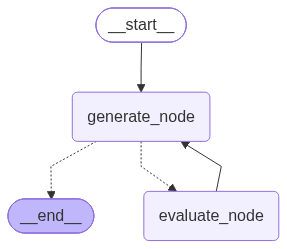

In [20]:
from IPython.display import Image, display

graph = graph.compile()

Image(graph.get_graph().draw_mermaid_png())

In [21]:
graph.invoke({
    "topic" : "car",
    "joke" : "",
    "funny_flag" :"",
    "feedback" : "",
    "max_iterations" : 0
})

KeyboardInterrupt: 